In [1]:
const MODEL = "iharm"
const MBH = 6.2e9
const SLOW_LIGHT = true
include("../src/main.jl");

Using model: iharm, change src/set_globals.jl to modify.


In [2]:
#path to folder with the arxiv name properly indexed
dump_filepath = "../../../sample_dump_SANE_a+0.94_MKS_0900.h5"


"../../../sample_dump_SANE_a+0.94_MKS_0900.h5"

In [3]:
trat_large = 20. 
const trat_small = 1. 
const beta_crit = 1.0 
const th_beg = 1.74e-2 
const sigma_cut = 1.0 
const sigma_cut_high = -1.0;

In [4]:
const params = read_header(dump_filepath);

Initializing grid from: ../../../sample_dump_SANE_a+0.94_MKS_0900.h5


Using mixed tp_over_te with trat_small = 1, trat_large = 20, and beta_crit = 1
Using Modified Kerr-Schild coordinates MKS
MKS parameters a: 0.937500 hslope: 0.300000 Rin: 1.177706 Rout: 1000.000000
Grid start (startx): 1.635684465252566e-01, 0.000000000000000e+00, 0.000000000000000e+00 stop (stopx): 6.907755278982137e+00, 1.000000000000000e+00, 6.283185307179586e+00
grid dx: 2.341731539047528e-02, 7.812500000000000e-03, 4.908738521234052e-02


In [5]:
const simulation_data = load_data(dump_filepath, trat_large);

Loading data from '../../../sample_dump_SANE_a+0.94_MKS_0900.h5' into 'iharm' module...
All primitives successfully loaded. Dimensions: (288, 128, 128)


In [6]:
# Observer distance in gravitational radii (Rg)
const ro = 1000.0

# Inclination angle (deg) — angle between the observer and the BH spin axis
const th = 163.0

# Azimuthal angle (deg) — rotation around the system
const phi = 0.0

# Image resolution — total geodesics traced = res^2
const res = 128
const pixels_x = 128
const pixels_y = 128

# Distance to the source (in parsecs, converted to code units)
const SourceD = 16.9e6 * PC

# Radius where ray integration stops
const Rstop = 100.0

# Event horizon radius for a Kerr black hole
const Rh = 1 + sqrt(1. - params.a * params.a)

# Observing frequency (Hz), e.g. 230 GHz for EHT-like images
const freq = 230e9

# Image plane size (in Rg), scaled from physical distance
const DXsize = SourceD / L_unit / MUAS_PER_RAD * 160
const DYsize = SourceD / L_unit / MUAS_PER_RAD * 160

# Field of view (radians)
const fovx = DXsize / ro
const fovy = DYsize / ro

# Image offsets (can be used to shift the camera)
const xoff = 0.0
const yoff = 0.0


0.0

In [17]:
# Calculate the camera position in native coordinates
Xcamera = MVec4(camera_position(ro, th, phi, params.a, params.Rout))

# Unitless frequency 
const freq_unitless = freq * HPL / (ME * CL * CL)

# Array that will hold the Intensity value for each pixel
Image = zeros(Float64, pixels_x, pixels_y)
midplane_crossings = zeros(Int, pixels_x, pixels_y)

# Number of threads used in the calculation
const nthreads = Threads.nthreads() + 1

println("Allocating workspaces for $nthreads threads...")
# Number of maximum steps in the geodesic calculation
const maxnstep = 15000

# Allocating the scratchpad vector for each thread
thread_trajs = [Vector{OfTrajM}(undef, maxnstep) for _ in 1:nthreads]
for t in 1:nthreads
    for k in 1:maxnstep
        thread_trajs[t][k] = OfTrajM(
            0.0, 
            MVec4(undef), MVec4(undef), MVec4(undef), MVec4(undef)
        )
    end
end

# This will hold the exact number of steps for each pixel.
const all_geodesics = Matrix{Vector{OfTrajM}}(undef, pixels_x, pixels_y)

# Allocate an array to hold the minimum time found by EACH thread
# Initialized to 0.0 because your photon times will be negative
thread_t0 = zeros(Float64, nthreads)

# tgeoi needs to find the maximum (closest to zero), so initialize very negative
thread_tgeoi = fill(-1e100, nthreads) 

# tgeof needs to find the minimum (most negative), so initialize at zero
thread_tgeof = zeros(Float64, nthreads)

p = Progress(
    pixels_x * pixels_y; 
    desc = "Raytracing Image...", 
    showspeed = true, 
    barlen = 30
)
ProgressMeter.ijulia_behavior(:clear)

println("Tracing Geodesics...")
Threads.@threads for i in 0:(pixels_x - 1)
    tid = Threads.threadid() 
    
    for j in 0:(pixels_y - 1)
        nstep, midplane_crossings[i+1,j+1] = get_pixel(
            thread_trajs[tid], i, j, Xcamera, 
            fovx, fovy, freq_unitless, 
            pixels_x, pixels_y, params.a, 
            Rh, params.Rout, Rstop, xoff, yoff
        ) 
        
        # Save to permanent storage
        all_geodesics[i + 1, j + 1] = thread_trajs[tid][1:nstep]

        final_step_time = thread_trajs[tid][nstep].X[1]
        if final_step_time < thread_t0[tid]
            thread_t0[tid] = final_step_time
        end

        # tgeoi and tgeof calculations following how ipole does it
        pixel_tgeoi = 1.0
        pixel_tgeof = 1.0
        
        for k in 1:nstep
            X = thread_trajs[tid][k].X
            K = thread_trajs[tid][k].Kcon
        
            log_r = X[2]          # must be log(r)
            t_coord = X[1]
            k_r = K[2]            # must match Kcon[1]
        
            if pixel_tgeoi > 0.0 && log_r < log(100.0)
                pixel_tgeoi = t_coord
            end
        
            if pixel_tgeof > 0.0 && log_r > log(100.0) && k_r < 0.0
                pixel_tgeof = t_coord
            end
        end
        
        final_step_time = thread_trajs[tid][nstep].X[1]
        

        if pixel_tgeoi < 0.0 && pixel_tgeoi > thread_tgeoi[tid]
            thread_tgeoi[tid] = pixel_tgeoi
        end
        
        if pixel_tgeof < 0.0 && pixel_tgeof < thread_tgeof[tid]
            thread_tgeof[tid] = pixel_tgeof
        elseif pixel_tgeof > 0.0 && final_step_time < thread_tgeof[tid]
            thread_tgeof[tid] = final_step_time
        end
        
        ProgressMeter.next!(
                p; 
                showvalues = [
                    (:thread_id, tid), 
                    (:pixel, "($i, $j)"), 
                    (:total_done, "$(i*pixels_y + j)/$(pixels_x * pixels_y)")
            ]
        )
    end
end

Image *= freq^3
finish!(p);

t0 = minimum(thread_t0)
tgeof = minimum(thread_tgeof) # The most negative time in the active zone (Oldest file needed)
tgeoi = maximum(thread_tgeoi) # The least negative time in the active zone (Newest file needed)

println("Calculated t0 (absolute longest time): $t0")
println("Calculated tgeof (oldest active time): $tgeof")
println("Calculated tgeoi (newest active time): $tgeoi")

# Eliminate arrays from RAM
thread_to = nothing
thread_tgeoi = nothing
thread_tgeof = nothing
thread_trajs = nothing
GC.gc()

Calculated t0 (absolute longest time): -1182.7820504202787
Calculated tgeof (oldest active time): -1182.7820504202787
Calculated tgeoi (newest active time): -909.3596668647253


Raytracing Image... 100%|██████████████████████████████| Time: 0:00:02 ( 0.15 ms/it)
    thread_id: 8
        pixel: (79, 127)
   total_done: 10239/16384


In [ ]:
#print images every 10M
ImageCadence = 10;



In [21]:
println("First image is gonna be produced at $(simulation_data[1].t - tgeof)")
println("At this time, we need files from $ ")

snap_A_time = simulation_data[1].t + tgeof
snap_B_time = simulation_data[1].t + tgeoi
println("simulation file: $(floor(snap_A_time)) and $(ceil(snap_B_time))")

#Define your base directory
GRMHD_snapshot_name_path = "/path/to/your/simulations/folder"

# Perform your cadence calculations
GRMHD_cadence = 5
t_A = floor(Int, snap_A_time / GRMHD_cadence) * GRMHD_cadence
t_B = t_A + GRMHD_cadence

#last snapshot
#t_B_target = ceil(Int, snap_B_time / GRMHD_cadence) * GRMHD_cadence

# Construct the full paths
# Using joinpath is the safest way to merge folder paths and filenames
file_A = joinpath(GRMHD_snapshot_name_path, "dump_$(t_A).h5")
file_B = joinpath(GRMHD_snapshot_name_path, "dump_$(t_B).h5")

println("Loading files:")
println(file_A)
println(file_B)

First image is gonna be produced at 5684.459891331488
simulation file: 3318.0 and 3593.0
Loading files:
/path/to/your/simulations/folder/dump_3315.h5
/path/to/your/simulations/folder/dump_3320.h5


Generating plots...


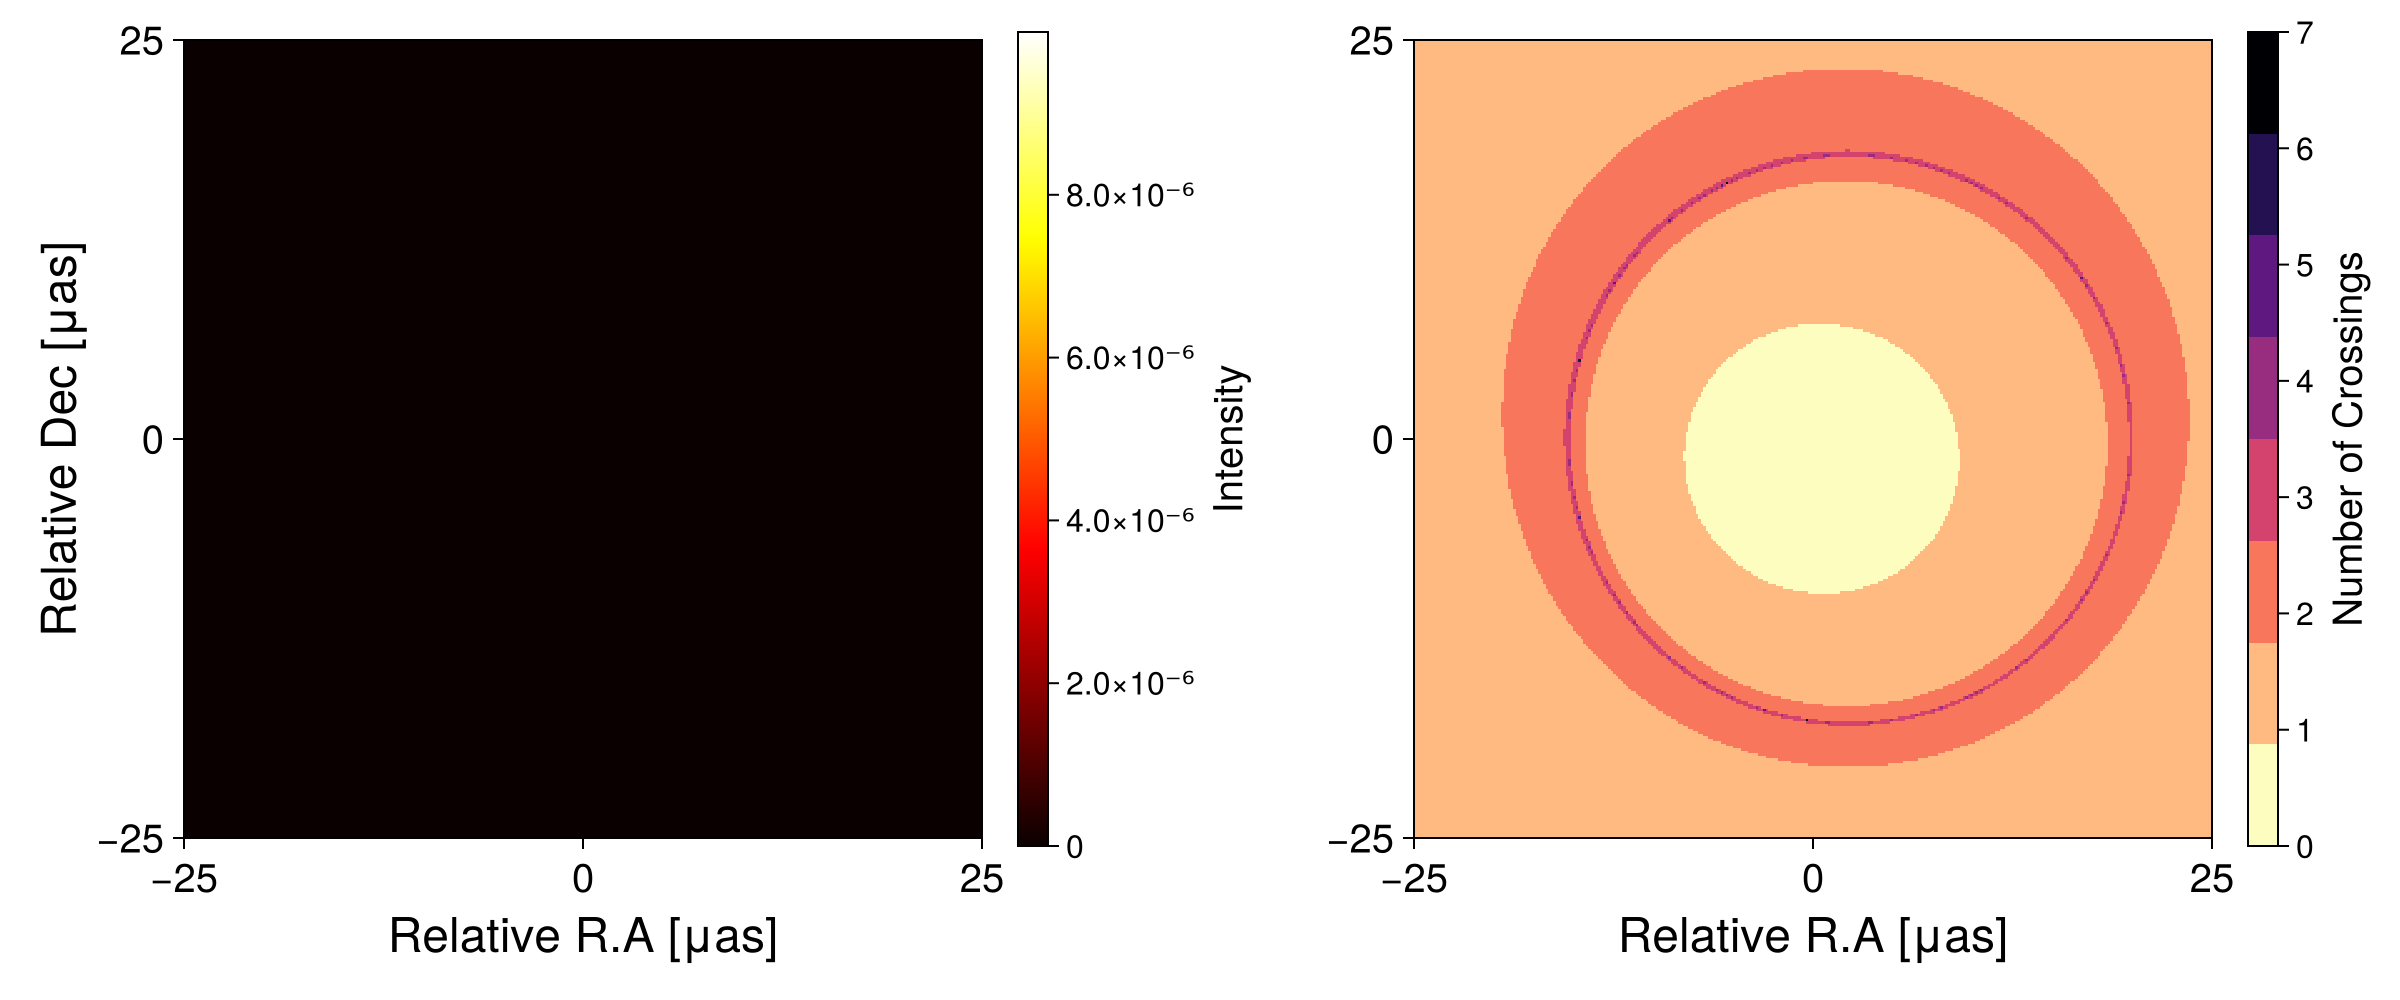

In [14]:
println("Generating plots...")
using CairoMakie

# Coordinate Conversions
d_kpc = 16.9
d_cm = d_kpc * 3.086e21            
fov_rg = fovx
half_fov_rg = fov_rg / 2

theta_rad = (half_fov_rg * L_unit) / d_cm   
theta_μas = theta_rad * MUAS_PER_RAD       
xlims = (-theta_μas, theta_μas)
ylims = (-theta_μas, theta_μas)

Ny, Nx = size(Image)
x = range(xlims[1], xlims[2], length=Nx)
y = range(ylims[1], ylims[2], length=Ny)

# Define your zoom limits
zoom_lims = (-25.0, 25.0)

# Figure Setup
fig = Figure(size = (1200, 500))

# --- Left Panel: Intensity ---
ax_img = Axis(fig[1, 1],
    xlabel = "Relative R.A [μas]",
    ylabel = "Relative Dec [μas]",
    xlabelsize = 24,
    ylabelsize = 24,
    xticklabelsize = 20,
    yticklabelsize = 20,
    # Lock limits to -30 to 30
    limits = (zoom_lims, zoom_lims),
    aspect = DataAspect()
)

# Safe Extrema (Crash fix for entirely black images)
cmin, cmax = extrema(Image)
if cmin == cmax
    cmax = cmin + 1e-5
end

hm_img = heatmap!(ax_img, x, y, Image;
    colormap = :hot,
    colorrange = (cmin, cmax)
)

Colorbar(fig[1, 2], hm_img;
    label = "Intensity",
    labelsize = 20,
    ticklabelsize = 16,
    width = 15
)

# --- Right Panel: Crossings ---
ax_cross = Axis(fig[1, 3],
    xlabel = "Relative R.A [μas]",
    xlabelsize = 24,
    xticklabelsize = 20,
    yticklabelsize = 20,
    # Lock limits to -30 to 30
    limits = (zoom_lims, zoom_lims),
    aspect = DataAspect()
)

# Colormap logic: Use a reversed magma map. 
# n=0 will be very light, and higher n will get progressively darker/sharper.
max_cross = maximum(midplane_crossings)
n_levels = min(15, max(2, max_cross + 1)) # +1 to ensure we count 0 as a level
discrete_colormap = cgrad(:magma, n_levels, categorical = true, rev = true)

cmin_cross = 0
cmax_cross = max(1, max_cross)

hm_cross = heatmap!(ax_cross, x, y, midplane_crossings;
    colormap = discrete_colormap,
    colorrange = (cmin_cross, cmax_cross)
)

tick_step = max_cross > 15 ? ceil(Int, max_cross / 5) : 1

Colorbar(fig[1, 4], hm_cross;
    label = "Number of Crossings",
    labelsize = 20,
    ticklabelsize = 16,
    width = 15,
    ticks = 0:tick_step:cmax_cross
)

colgap!(fig.layout, 2, 40)

# Display the final plot
fig